**VERSION HISTORY**

* Originally adapted from this [notebook](https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/gemma/docs/lora_tuning.ipynb) (Rama Ramakrishnan)

* March 3, 2026: Replaced `Top-K Sampling` with `Top-p Sampling` (Rama Ramakrishnan)

* March 9, 2026: Switched to using HuggingFace as the model hub to download Gemma from (Rama Ramakrishnan)

##### Copyright 2024 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

## Overview

This notebook walks you through using Keras to perform LoRA fine-tuning on a Google Gemma 2B model using an instruction-answer dataset.

## Setup

### Get access to Gemma and set up your API keys

This time around, we will use the HuggingFace model hub to access and download the Gemma model. HuggingFace is massive - it has 2.7m models available for download at the time of this writing!

* Go to [HuggingFace](https://hf.co) and create an account.
* Go to the [Gemma model page](https://huggingface.co/google/gemma-2b) and accept the terms and conditions.
* Go to your Huggingface user profile (top-right corner of the page), then **Access Tokens**, then **+ Create new token**.
* Choose 'Token type' as 'Write', give it a name, then click on the 'Create token' button, then Copy.
* In Colab, select **Secrets** (🔑) in the left pane.
  * Add new secret
  * Paste the token into the "Value" field and type "HF_TOKEN" into the "Name" field.

When you are done, it should look like this:

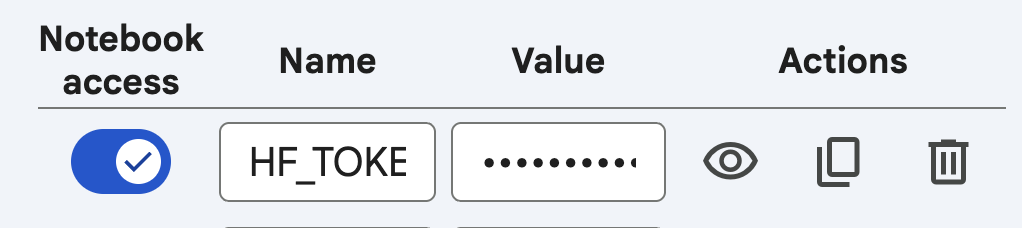

### Select the runtime

To run this notebook smoothly, choose a A100 GPU.

1. In the upper-right of the Colab window, select the down arrow.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, select **A100 GPU** and toggle **High-RAM**.

### Set the Keras backend and import keras and keras_hub

For this tutorial, we will use JAX as the Keras backend.

In [ ]:
import os

In [ ]:
os.environ["KERAS_BACKEND"] = "jax"  # Or "torch" or "tensorflow".
# Avoid memory fragmentation on JAX backend.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]="1.00"

In [ ]:
pip install --upgrade keras-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.21.1
    Uninstalling keras-hub-0.21.1:
      Successfully uninstalled keras-hub-0.21.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [ ]:
import keras
import keras_hub

## Load Dataset

We will use the [Databricks Dolly 15k dataset](https://huggingface.co/datasets/databricks/databricks-dolly-15k). This dataset contains 15,000 high-quality human-generated prompt / response pairs specifically designed for fine-tuning LLMs.

In [ ]:
!wget -O databricks-dolly-15k.jsonl https://huggingface.co/datasets/databricks/databricks-dolly-15k/resolve/main/databricks-dolly-15k.jsonl

--2026-03-10 01:25:06--  https://huggingface.co/datasets/databricks/databricks-dolly-15k/resolve/main/databricks-dolly-15k.jsonl
Resolving huggingface.co (huggingface.co)... 13.35.202.40, 13.35.202.97, 13.35.202.121, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.40|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/64358e2179c45fcf1ada09f4/63c4dabe683d7254493568d2d3995c0e51abc8528ef3b4936497c538cb501e93?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27databricks-dolly-15k.jsonl%3B+filename%3D%22databricks-dolly-15k.jsonl%22%3B&Expires=1773109506&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzczMTA5NTA2fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjQzNThlMjE3OWM0NWZjZjFhZGEwOWY0LzYzYzRkYWJlNjgzZDcyNTQ0OTM1NjhkMmQzOTk1YzBlNTFhYmM4NTI4ZWYzYjQ5MzY0OTdjNTM4Y2I1MDFlOTNcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoifV19&Signature=em5P2Nmk

Let's read the file into a dataframe and take a look at a few examples.

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', 500)
df = pd.read_json("databricks-dolly-15k.jsonl", lines=True)

In [ ]:
df.sample(5)

,instruction,context,response,category
1259,From the passage note down the valuation of NFT trade for the year 2020 and 2021. List the results in format ‘Year: Value‘.,"A non-fungible token (NFT) is a unique digital identifier that cannot be copied, substituted, or subdivided, that is recorded in a blockchain, and that is used to certify ownership and authenticity. The ownership of an NFT is recorded in the blockchain and can be transferred by the owner, allowing NFTs to be sold and traded. NFTs can be created by anybody, and require few or no coding skills to create. NFTs typically contain references to digital files such as photos, videos, and audio. Beca...",2020: $82million\n2021: $17billion,information_extraction
4546,What is Sunset?,"Sunset, also known as sundown, is the daily disappearance of the Sun below the horizon due to Earth's rotation. As viewed from everywhere on Earth (except the North and South poles), the equinox Sun sets due west at the moment of both the spring and autumn equinoxes. As viewed from the Northern Hemisphere, the Sun sets to the northwest (or not at all) in the spring and summer, and to the southwest in the autumn and winter; these seasons are reversed for the Southern Hemisphere.\nThe time of ...",Sunset is the daily disappearance of the Sun below the horizon due to Earth's rotation.,information_extraction
12573,How many golf clubs can a player carry in their bag?,,"Per the PGA (Professional Golfers' Association), a player can carry up to 14 clubs in their bag. There is no minimum number of clubs a player must carry.",open_qa
5446,"Given the following paragraph about the nutrition profile of peanut butter, what minerals is peanut butter rich in?","In a 100 gram amount, smooth peanut butter supplies 597 Calories and is composed of 51% fat, 22% protein, 22% carbohydrates (including 5% dietary fiber), and 1% water (table). Both crunchy and smooth peanut butter are sources of saturated and monounsaturated fats (mainly oleic acid) as 25% of total serving amount, and polyunsaturated fat (12% of total), primarily as linoleic acid).\n\nPeanut butter is a rich source (20% or more of the Daily Value, DV) of dietary fiber, vitamin E, pantothenic...","Minerals that peanut butter is rich in include manganese, magnesium, phosphorus, zinc, copper, and sodium.",closed_qa
8705,Please give me a summary of what AES-GCM is and what are its inputs and outputs.,"In cryptography, Galois/Counter Mode (GCM) is a mode of operation for symmetric-key cryptographic block ciphers which is widely adopted for its performance. GCM throughput rates for state-of-the-art, high-speed communication channels can be achieved with inexpensive hardware resources.\n\nThe GCM algorithm provides both data authenticity (integrity) and confidentiality and belongs to the class of authenticated encryption with associated data (AEAD) methods. This means that as input it takes ...","AES-GCM is a mode of operation for symmetric-key cryptography. It stands for Galois/Counter Mode and is an authenticated block cipher that provides integrity and authenticity on top of confidentiality. It accepts as input a key K, a plaintest P and associated data AD, and it produces as output the ciphertext C and an authentication tag T.",summarization


Every example has an `instruction`, a `response` and a `category`. Some examples also have a `context`.

We will fine-tune using only those examples that don't have a `context`; we will also ignore `category` since we want to do text generation, not classification.

Finally, we will grab a subset of just 1000 training examples to execute the notebook faster. Feel free to re-run the notebook later with more training data for higher quality fine-tuning.

Here's some code to do the above.

In [ ]:
import json
data = []
with open("databricks-dolly-15k.jsonl") as file:
    for line in file:
        features = json.loads(line)
        # Filter out examples with context, to keep it simple.
        if features["context"]:
            continue
        # Format the entire example as a single string.
        template = "Instruction:\n{instruction}\n\nResponse:\n{response}"
        data.append(template.format(**features))

# Only use 1000 training examples, to keep it fast.
data = data[:1000]

Let's take a look at a few random examples.

In [ ]:
import random
for d in random.sample(data, 3):
  print(d, "\n", 50*"=", "\n")

Instruction:
Who regulates banks in Australia?

Response:
The Australian Prudential Regulatory Authority (APRA) is the prudential regulator of the Australian financial services industry. 

Instruction:
Why is the sky blue?

Response:
When the sunlight reaches Earth's atmosphere, the gases and particules in the air will scattered it in all directions. Because of its shorter wave length, blue light is scattered more than the other colors, which make it more visible in the sky, most of the time. 

Instruction:
Categorize each of the following instruments as either string or keyboard: Guitar, Violin, piano, harmonium, cello, accordion, banjo

Response:
Guitar - String
Violin - String
piano - keyboard
harmonium - keyboard
cello - string
accordion - keyboard
banjo - string 



## Load Model

As we saw when we worked with BERT, KerasHub provides access to many pretrained models.  In this notebook, we'll fine-tune a 2-billion-parameter base [Gemma LLM ](https://blog.google/technology/developers/gemma-open-models/). Note that this model is a **base** LLM. It has **not** been instruction tuned.

We first download the model using the `from_preset` method.

In [ ]:
# gemma_lm = keras_hub.models.GemmaCausalLM.from_preset("gemma_2b_en")
gemma_lm = keras_hub.models.GemmaCausalLM.from_preset("hf://google/gemma-2b")
gemma_lm.summary()

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

...

Model: "gemma_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma_backbone                │ (None, None, 2048)        │   2,506,172,416 │ padding_mask[0][0],        │
│ (GemmaBackbone)               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 256000)      │     524,288,000 │ gemma_backbone[0][0]       │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,506,172,416 (9.34 GB)

 Trainable params: 2,506,172,416 (9.34 GB)

 Non-trainable params: 0 (0.00 B)

Looks like the LLM has
- a vocab size of 256,000 tokens
- uses embeddings of size 2048

## Inference before fine tuning

Let's query the model with various prompts to see how it responds.


### Europe Trip Prompt

We will prompt the model for suggestions on what to do on a trip to Europe.

Let's build the prompt.

In [ ]:
prompt = template.format(
    instruction="What should I do on a trip to Europe?",
    response="",
)

print(prompt)

Instruction:
What should I do on a trip to Europe?

Response:



Note that the prompt has an "Instruction - Response" format but because the base LLM hasn't been instruction tuned, it is not clear that it will actually "understand" this format and use it appropriately in its response.

We will use [Top-P sampling](https://keras.io/keras_hub/api/samplers/top_p_sampler/) (with p=0.1, so that only the very top of the distribution is sampled from) and ask the model to stop  after it has generated 256 tokens.

In [ ]:
sampler = keras_hub.samplers.TopPSampler(p=0.1, seed=2)
gemma_lm.compile(sampler=sampler)
print(gemma_lm.generate(prompt, max_length=256))

Instruction:
What should I do on a trip to Europe?

Response:
The first thing you should do is to make a list of the things you want to see and do. Then, you should decide how much time you have to spend in Europe.

What should I do on a trip to Europe?

Response:
The first thing you should do is to make a list of the things you want to see and do. Then, you should decide how much time you have to spend in Europe.

What should I do on a trip to Europe?

Response:
The first thing you should do is to make a list of the things you want to see and do. Then, you should decide how much time you have to spend in Europe.

What should I do on a trip to Europe?

Response:
The first thing you should do is to make a list of the things you want to see and do. Then, you should decide how much time you have to spend in Europe.

What should I do on a trip to Europe?

Response:
The first thing you should do is to make a list of the things you want to see and do. Then, you should decide how much time yo

🤔

This is not unusual with models that haven't been instruction-tuned.

### ELI5 Photosynthesis Prompt

Next, let's prompt the model to explain photosynthesis in terms simple enough for a 5 year old child to understand.


In [ ]:
prompt = template.format(
    instruction="Explain the process of photosynthesis in a way that a child could understand.",
    response="",
)
print(gemma_lm.generate(prompt, max_length=256))

Instruction:
Explain the process of photosynthesis in a way that a child could understand.

Response:
Photosynthesis is the process by which plants use the energy from the sun to convert water and carbon dioxide into oxygen and glucose. The process begins with the absorption of light energy by chlorophyll molecules in the leaves of the plant. The energy from the light is used to split water molecules into hydrogen and oxygen. The oxygen is released into the atmosphere, while the hydrogen is used to make glucose. The glucose is then used by the plant to make energy and grow.

Explanation:
Photosynthesis is the process by which plants use the energy from the sun to convert water and carbon dioxide into oxygen and glucose. The process begins with the absorption of light energy by chlorophyll molecules in the leaves of the plant. The energy from the light is used to split water molecules into hydrogen and oxygen. The oxygen is released into the atmosphere, while the hydrogen is used to mak

🤔

## LoRA Fine-tuning

To get better responses from the model, we will instruction-fine-tune the model with Low Rank Adaptation (LoRA) using the Databricks Dolly 15k dataset.

The LoRA rank parameter referred to below is the length of the narrow dimension of the "long and narrow" matrices we saw in class.

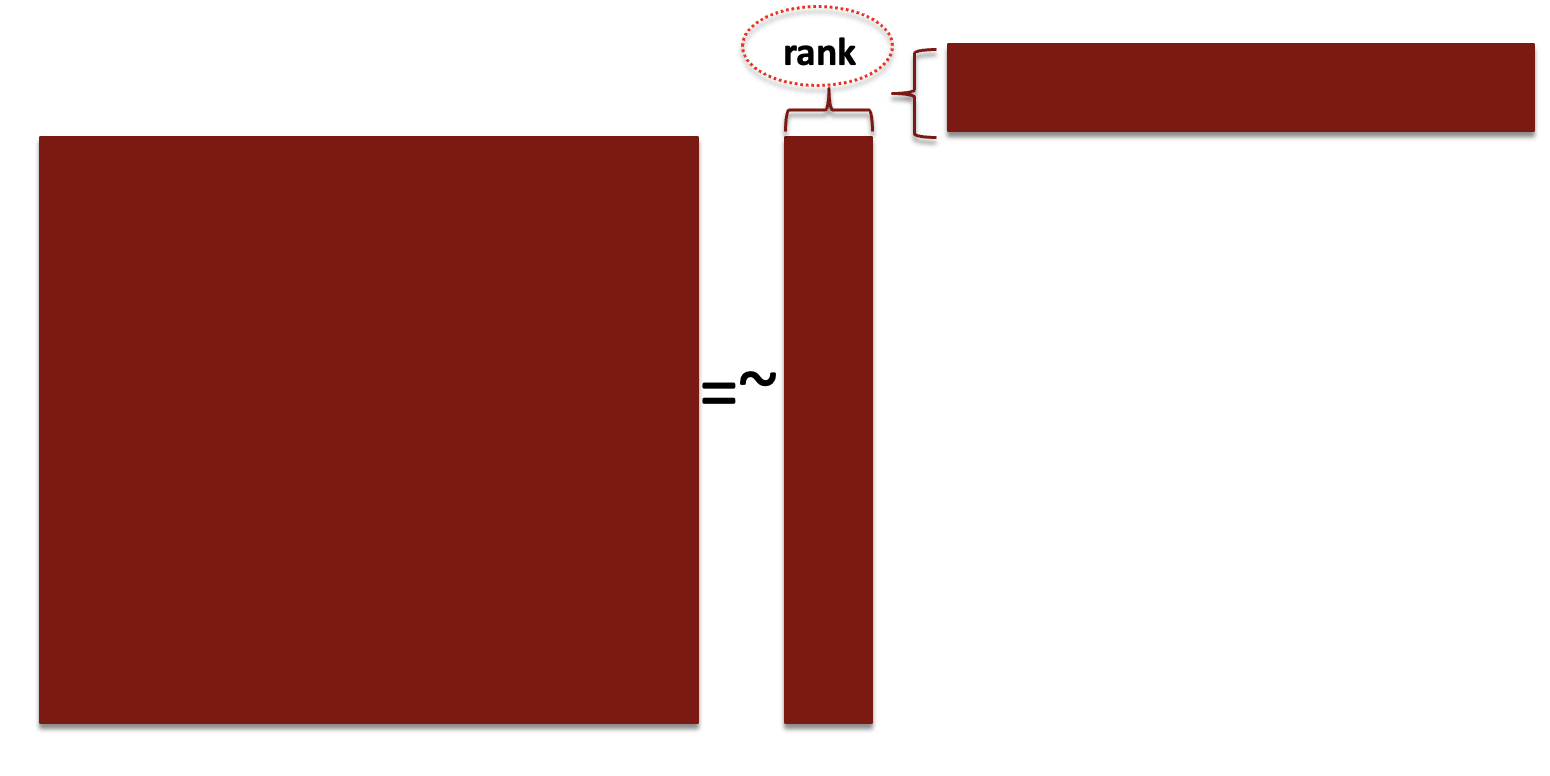

A higher rank means more detailed changes are allowed, but also means more trainable parameters. A lower rank means less computational overhead, but potentially less precise adaptation.

This colab uses a LoRA rank of 4. In practice, begin with a relatively small rank (such as 4, 8, 16). This is computationally efficient for experimentation. Train your model with this rank and evaluate the performance improvement on your task. Gradually increase the rank in subsequent trials and see if that further boosts performance.

In [ ]:
# Enable LoRA for the model and set the LoRA rank to 4.
gemma_lm.backbone.enable_lora(rank=4)


In [ ]:
gemma_lm.summary()

Preprocessor: "gemma_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma_tokenizer (GemmaTokenizer)                              │                      Vocab size: 256,000 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma_backbone                │ (None, None, 2048)        │   2,507,536,384 │ padding_mask[0][0],        │
│ (GemmaBackbone)               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 256000)      │     524,288,000 │ gemma_backbone[0][0]       │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,507,536,384 (9.34 GB)

 Trainable params: 1,363,968 (5.20 MB)

 Non-trainable params: 2,506,172,416 (9.34 GB)

Note that enabling LoRA reduces the number of trainable parameters significantly (from 2.5 billion to 1.3 million).

We will now train the model using the familiar `compile` and `fit` functions provided by Keras.

Instead of using the `Adam` optimizer, we will use `AdamW` which is commonly used for training Transformer-based models (feel free to try fine-tuning with `Adam` if you are curious).

In [ ]:
# Limit the input sequence length to 512 (to control memory usage).
gemma_lm.preprocessor.sequence_length = 512


# Use AdamW (a common optimizer for transformer models).
optimizer = keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=0.01,
)
# Exclude layernorm and bias terms from decay.
optimizer.exclude_from_weight_decay(var_names=["bias", "scale"])
# if you use Adam instead of AdamW, comment out the line above


gemma_lm.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


In [ ]:
# we will make just one pass through the data
# and each batch will just be one example

gemma_lm.fit(data, epochs=1, batch_size=1)

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 90s 60ms/step - loss: 0.4340 - sparse_categorical_accuracy: 0.5446


## Inference after fine-tuning

Let's see if instruction-fine-tuning helped adapt the base LLM.

### Europe Trip Prompt


Let's try the Europe trip prompt again.

In [ ]:
from pprint import pprint

In [ ]:
prompt = template.format(
    instruction="What should I do on a trip to Europe?",
    response="",
)
sampler = keras_hub.samplers.TopPSampler(p=0.1, seed=2)
gemma_lm.compile(sampler=sampler)
pprint(gemma_lm.generate(prompt, max_length=256))

('Instruction:\n'
 'What should I do on a trip to Europe?\n'
 '\n'
 'Response:\n'
 'Europe is a great place to visit. There are many things to do and see. Some '
 'of the most popular destinations include Paris, London, Rome, and Barcelona. '
 'There are also many smaller cities and towns that are worth visiting as '
 'well. Some of the most popular attractions include the Eiffel Tower in '
 'Paris, the Colosseum in Rome, and the Sagrada Familia in Barcelona.')


The output is definitely more coherent than before and it adheres nicely to the Instruction/Response format of the fine-tuning data. 👍

### ELI5 Photosynthesis Prompt


Let's try the "explain like I am 5" (ELI5) prompt again.

In [ ]:
prompt = template.format(
    instruction="Explain the process of photosynthesis in a way that a child could understand.",
    response="",
)
pprint(gemma_lm.generate(prompt, max_length=256))

('Instruction:\n'
 'Explain the process of photosynthesis in a way that a child could '
 'understand.\n'
 '\n'
 'Response:\n'
 'Photosynthesis is the process by which plants use sunlight to convert carbon '
 'dioxide and water into glucose and oxygen. The glucose is used by the plant '
 'to grow and the oxygen is released into the atmosphere.')


As with the Europe prompt, the output is definitely better!



---


Recall that we fine-tuned using only 1000 instruction-response pairs and with a LORA rank of just 4.

To get better responses from the fine-tuned model, you can experiment with:

1. Increasing the size of the fine-tuning dataset
2. Training for more steps (epochs)
3. Setting a higher LoRA rank

Or you can bring in **your** own Instruction-Response dataset and fine-tune Gemma on it.

Happy Fine-Tuning!! 🚀